In [40]:
import pandas as pd
import numpy as np
import re
import csv
from matplotlib import pyplot as plt

In [15]:
data = pd.read_csv("poem_data_with_birth.csv")

In [16]:
data.head()

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period
0,The New Church,Lucia Cherciu,"The old cupola glinted above the clouds, shone...",NaN,Fear,NaN,NaN
1,Look for Me,Ted Kooser,Look for me under the hood\r\r\nof that old Ch...,NaN,Sadness,1939.0,1941-1970
2,Wild Life,Grace Cavalieri,"Behind the silo, the Mother Rabbit\r\r\nhunche...",NaN,Surprise,1932.0,1941-1970
3,Umbrella,Connie Wanek,When I push your button\r\r\nyou fly off the h...,NaN,Fear,1952.0,1971-Present
4,Sunday,January Gill O'Neil,You are the start of the week\r\r\nor the end ...,NaN,Anger,NaN,NaN


In [17]:
LINESEP_RE = re.compile(r'\r+\n')
WHITESPACE_RE = re.compile(r'\s+')
TOKEN_RE = re.compile(r'<linesep>|\b\w+\b')

def preprocess(text):
    text = text.lower()
    text = LINESEP_RE.sub(' <linesep> ', text)
    text = WHITESPACE_RE.sub(' ', text)
    return TOKEN_RE.findall(text)

poems = data.iloc[:,2]
tokenized_poems = [preprocess(poem) for poem in poems]

In [22]:
def compute_line_stats(tokenized_poems):
    line_lengths = []
    lines_per_poem = []

    for poem in tokenized_poems:
        current_line_len = 0
        line_count = 0

        for token in poem:
            if token == "<linesep>":
                # end of a line
                line_lengths.append(current_line_len)
                current_line_len = 0
                line_count += 1
            else:
                current_line_len += 1

        # handle last line if poem doesn't end with <linesep>
        if current_line_len > 0:
            line_lengths.append(current_line_len)
            line_count += 1

        lines_per_poem.append(line_count)

    # compute statistics
    avg_line_len = np.mean(line_lengths)
    std_line_len = np.std(line_lengths)

    avg_num_lines = np.mean(lines_per_poem)
    std_num_lines = np.std(lines_per_poem)

    return avg_line_len, avg_num_lines

In [23]:
def classify_poems(tokenized_poems, avg_line_len, avg_num_lines):
    classifications = []

    for poem in tokenized_poems:
        line_lengths = []
        current_line_len = 0

        for token in poem:
            if token == "<linesep>":
                line_lengths.append(current_line_len)
                current_line_len = 0
            else:
                current_line_len += 1

        if current_line_len > 0:
            line_lengths.append(current_line_len)

        poem_avg_line_len = np.mean(line_lengths) if line_lengths else 0
        poem_num_lines = len(line_lengths)

        if poem_avg_line_len <= avg_line_len:
            line_type = "sl"  # short line
        else:
            line_type = "ll"  # long line

        if poem_num_lines <= avg_num_lines:
            poem_type = "sp"  # short poem
        else:
            poem_type = "lp"  # long poem

        classifications.append(f"{line_type}-{poem_type}")

    return classifications

In [25]:
avg_line_len, avg_num_lines = compute_line_stats(tokenized_poems)
format_categories = classify_poems(tokenized_poems, avg_line_len, avg_num_lines)
print(avg_line_len, avg_num_lines)

9.891336486463954 26.18072026191342


In [26]:
data["Format"] = format_categories

In [27]:
data.head()

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period,Format
0,The New Church,Lucia Cherciu,"The old cupola glinted above the clouds, shone...",NaN,Fear,NaN,NaN,sl-sp
1,Look for Me,Ted Kooser,Look for me under the hood\r\r\nof that old Ch...,NaN,Sadness,1939.0,1941-1970,sl-sp
2,Wild Life,Grace Cavalieri,"Behind the silo, the Mother Rabbit\r\r\nhunche...",NaN,Surprise,1932.0,1941-1970,sl-lp
3,Umbrella,Connie Wanek,When I push your button\r\r\nyou fly off the h...,NaN,Fear,1952.0,1971-Present,sl-lp
4,Sunday,January Gill O'Neil,You are the start of the week\r\r\nor the end ...,NaN,Anger,NaN,NaN,sl-sp


In [31]:
print(data.iloc[0, 2])

The old cupola glinted above the clouds, shone
among fir trees, but it took him an hour
for the half mile all the way up the hill. As he trailed,
the village passed him by, greeted him,
asked about his health, but everybody hurried
to catch the mass, left him leaning against fences,
measuring the road with the walking stick he sculpted.
He yearned for the day when the new church
would be built—right across the road. Now
it rises above the moon: saints in frescoes
meet the eye, and only the rain has started to cut
through the shingles on the roof of his empty
house. The apple trees have taken over the sky,
sequestered the gate, sidled over the porch.


In [32]:
print(data.iloc[3, 2])

When I push your button
you fly off the handle,
old skin and bones,
black bat wing.
We're alike, you and I.
Both of us
resemble my mother,
so fierce in her advocacy
on behalf of
the most vulnerable child
who'll catch his death
in this tempest.
Such a headwind!
Sometimes it requires
all my strength
just to end a line.
But when the wind is at
my back, we're likely
to get carried away, and say
something we can never retract,
something saturated from the ribs
down, an old stony
word like ruin. You're what roof
I have, frail thing,
you're my argument
against the whole sky.
You're the fundamental difference
between wet and dry.


In [42]:
stats_format = (
    data
    .groupby(["Format"])
    .size()
    .reset_index(name="Count")
)
stats_format

,Format,Count
0,ll-lp,320
1,ll-sp,5637
2,sl-lp,4054
3,sl-sp,3734


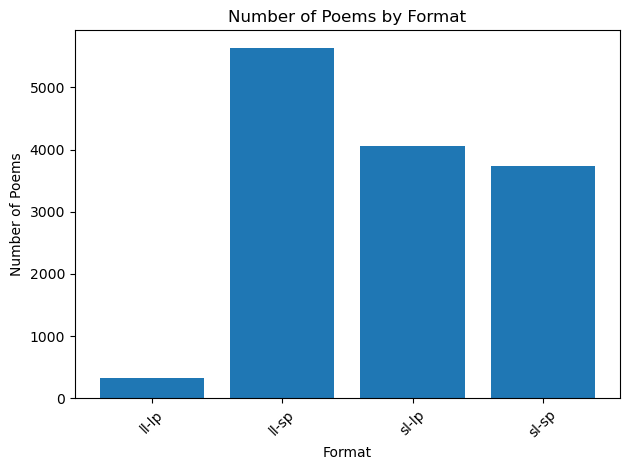

In [43]:
plt.figure()
plt.bar(stats_format["Format"], stats_format["Count"])

plt.xlabel("Format")
plt.ylabel("Number of Poems")
plt.title("Number of Poems by Format")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/fig_format_stats.png", dpi=300)
plt.show()

In [36]:
data.to_csv(
    'all_poems.csv',
    index=False,
    quoting=csv.QUOTE_ALL
)